In [1]:
# Step 1: create the DataFrame
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 2. Load dataset from CSV
data= pd.read_csv('heart_disease.csv')  

df = pd.DataFrame(data)

# Step 2: Encode categorical variables
categorical_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Step 3: Convert boolean to int
df_encoded['fbs'] = df_encoded['fbs'].fillna(False).astype(int)
df_encoded['exang'] = df_encoded['exang'].fillna(False).astype(int)

# Step 4: Create binary target variable
df_encoded['target'] = df_encoded['num'].apply(lambda x: 1 if x > 0 else 0)

# Step 5: Drop unnecessary columns
X = df_encoded.drop(['id', 'dataset', 'num', 'target'], axis=1)
y = df_encoded['target']


#  Step 6: Final NaN check and fix
X = X.fillna(X.median())  # Replace NaNs with column medians (safe for numeric data)


# Step 7: Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Fit the model (this will now work)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


# Step 9: Predict and evaluate
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8369565217391305

Confusion Matrix:
 [[64 18]
 [12 90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.78      0.81        82
           1       0.83      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



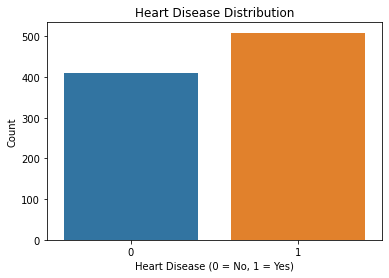

In [2]:
sns.countplot(x='target', data=df_encoded)
plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


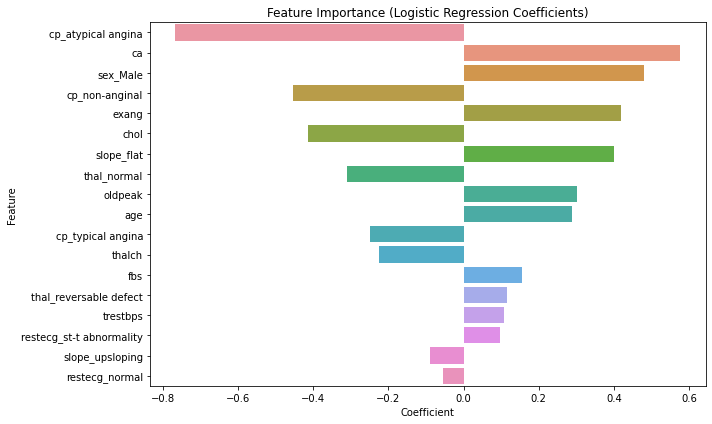

In [3]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.tight_layout()
plt.show()


In [4]:
# Model training & evaluation
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ⬇️ ADD VISUALIZATIONS BELOW THIS LINE


Accuracy: 0.8369565217391305

Confusion Matrix:
 [[64 18]
 [12 90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.78      0.81        82
           1       0.83      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



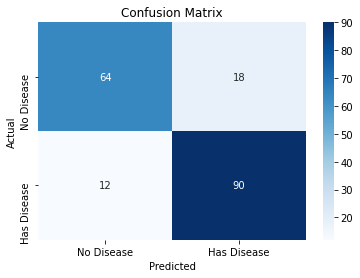

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No Disease", "Has Disease"], 
            yticklabels=["No Disease", "Has Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


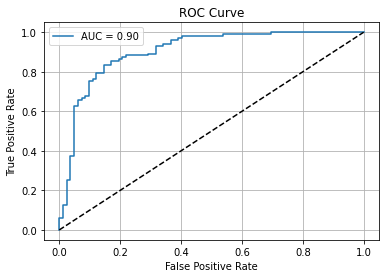

In [6]:
#ROC Curve with AUC
#Visualizes the tradeoff between true positive rate and false positive rate.

from sklearn.metrics import roc_curve, roc_auc_score

y_probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0,1], [0,1], 'k--')  # Diagonal line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()